In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, r2_score
from transformers import AutoTokenizer, AutoModel
import os
import math
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold'})

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 INITIALIZING SOTA 2026 ENTERPRISE TRAINING ON: {device}")
# Create directory to save report images
os.makedirs('report_plots', exist_ok=True)

🚀 INITIALIZING SOTA 2026 ENTERPRISE TRAINING ON: cuda


In [21]:
print("\n--- [1/6] Loading Data & Generating Deep EDA Plots ---")

DATA_PATH = '/content/Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv'
df = pd.read_csv(DATA_PATH)

df['start_datetime'] = pd.to_datetime(df['start_datetime'], errors='coerce')
df['closed_datetime'] = pd.to_datetime(df['closed_datetime'], errors='coerce')
df['impact_duration_mins'] = (df['closed_datetime'] - df['start_datetime']).dt.total_seconds() / 60.0
df = df[(df['impact_duration_mins'] >= 5) & (df['impact_duration_mins'] <= 1440)].copy()

df['hour'] = df['start_datetime'].dt.hour
df['hour_sin'] = np.sin(2 * math.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * math.pi * df['hour'] / 24.0)
df['is_weekend'] = df['start_datetime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

df['event_type'] = df['event_type'].fillna('unplanned')
df['event_cause'] = df['event_cause'].fillna('others')
df['priority'] = df['priority'].fillna('Low')
df['requires_road_closure'] = df['requires_road_closure'].apply(lambda x: 1 if str(x).upper() == 'TRUE' else 0)

def assign_manpower(row):
    if row['priority'] == 'High' and row['requires_road_closure'] == 1: return 3
    elif row['priority'] == 'High': return 2
    elif row['requires_road_closure'] == 1: return 1
    return 0
df['manpower_target'] = df.apply(assign_manpower, axis=1)


--- [1/6] Loading Data & Generating Deep EDA Plots ---


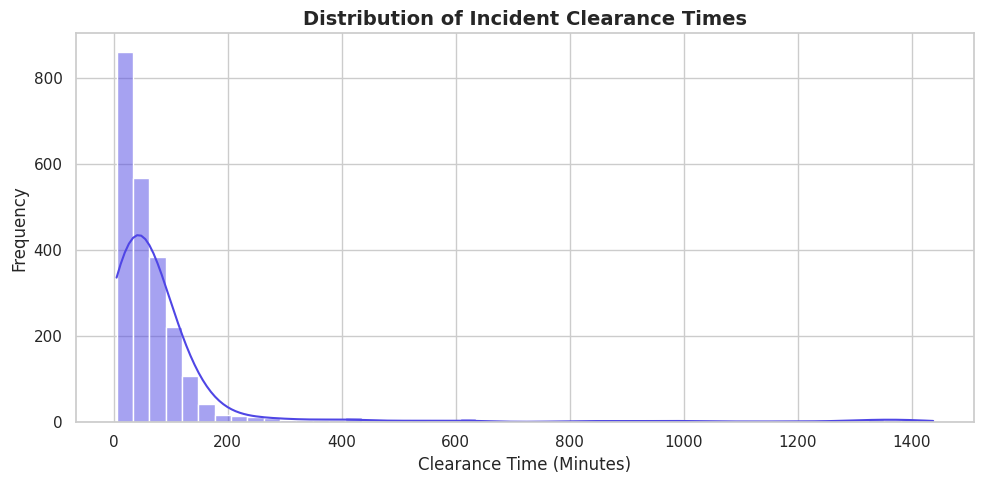

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['impact_duration_mins'], bins=50, kde=True, color='#4F46E5')
plt.title('Distribution of Incident Clearance Times')
plt.xlabel('Clearance Time (Minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('report_plots/01_Duration_Distribution.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

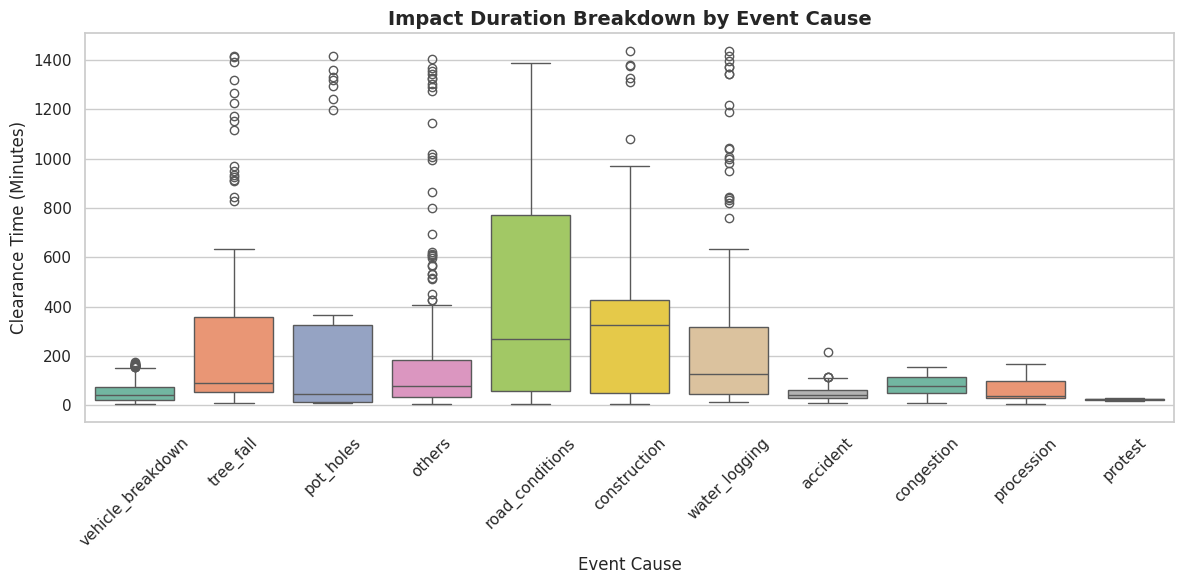

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='event_cause', y='impact_duration_mins', data=df, palette='Set2')
plt.title('Impact Duration Breakdown by Event Cause')
plt.xlabel('Event Cause')
plt.ylabel('Clearance Time (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('report_plots/02_Cause_vs_Duration.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

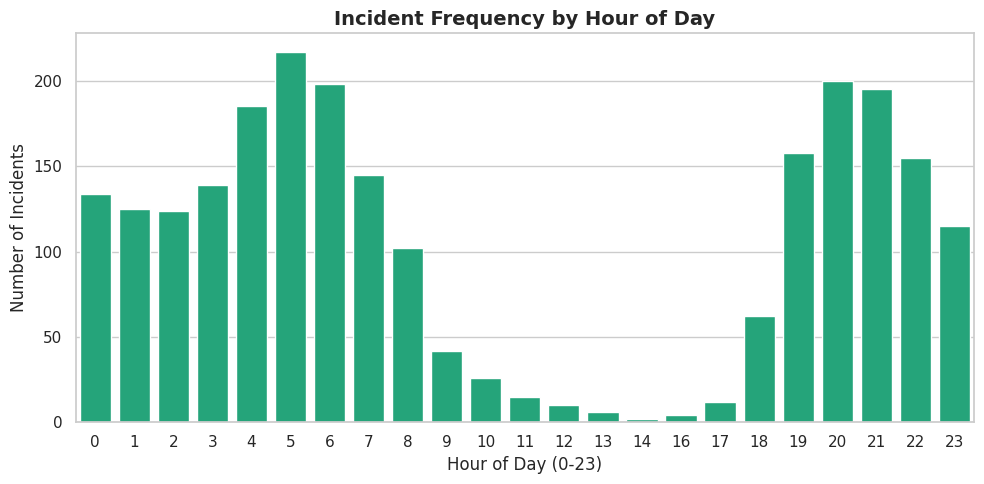

In [24]:
plt.figure(figsize=(10, 5))
hour_counts = df['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, color='#10B981')
plt.title('Incident Frequency by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig('report_plots/03_Hourly_Incidents.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

In [25]:
encoder_cause = LabelEncoder()
df['event_cause_idx'] = encoder_cause.fit_transform(df['event_cause'])
encoder_priority = LabelEncoder()
df['priority_idx'] = encoder_priority.fit_transform(df['priority'])

N_NODES = 100
coords = df[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=N_NODES, random_state=42, n_init=10)
df['graph_node_id'] = kmeans.fit_predict(coords)

Y_duration_raw = df['impact_duration_mins'].values
Y_duration_log = np.log1p(Y_duration_raw)
Y_manpower = df['manpower_target'].values

class_counts = np.bincount(Y_manpower, minlength=4)
total_samples = len(Y_manpower)
class_weights = total_samples / (4.0 * (class_counts + 1e-5))
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Calculated Class Weights to prevent bias: {class_weights}")

Calculated Class Weights to prevent bias: [0.78928095 5.98737313 0.41020761 7.79934108]


In [26]:
print("\n--- [2/6] Extracting LLM Semantic Embeddings ---")
if os.path.exists('sota_nlp_cache.npy'):
    print("✅ Loading cached LLM Semantic Embeddings...")
    X_text = np.load('sota_nlp_cache.npy')
else:
    df['description'] = df['description'].fillna('')
    df['combined_text'] = df['event_type'] + ": " + df['description']
    tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
    nlp_model = AutoModel.from_pretrained("bert-base-multilingual-cased").to(device)

    text_embeddings = []
    for text in tqdm(df['combined_text'].tolist()):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=32).to(device)
        with torch.no_grad():
            outputs = nlp_model(**inputs)
            text_embeddings.append(outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy())
    X_text = np.array(text_embeddings)
    np.save('sota_nlp_cache.npy', X_text)

X_features = df[['graph_node_id', 'hour_sin', 'hour_cos', 'is_weekend',
                 'event_cause_idx', 'priority_idx', 'requires_road_closure']].values

class TrafficDataset(Dataset):
    def __init__(self, X, X_t, Y_d, Y_m):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.X_t = torch.tensor(X_t, dtype=torch.float32)
        self.Y_d = torch.tensor(Y_d, dtype=torch.float32) # LOG-TRANSFORMED
        self.Y_m = torch.tensor(Y_m, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.X_t[idx], self.Y_d[idx], self.Y_m[idx]

dataset = TrafficDataset(X_features, X_text, Y_duration_log, Y_manpower)
train_size = int(0.75 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


--- [2/6] Extracting LLM Semantic Embeddings ---
✅ Loading cached LLM Semantic Embeddings...


In [27]:
print("\n--- [3/6] Initializing True Causal T-Learner STGNN ---")
class SOTA_CausalUrbanGPT_TLearner(nn.Module):
    def __init__(self, num_nodes=100, node_features=6, embed_dim=128, text_embed_dim=768):
        super().__init__()
        self.node_source_embed = nn.Parameter(torch.randn(num_nodes, 32))
        self.node_target_embed = nn.Parameter(torch.randn(32, num_nodes))

        self.feature_embed = nn.Linear(node_features, embed_dim)
        self.tcn = nn.Conv1d(in_channels=embed_dim, out_channels=embed_dim, kernel_size=1, dilation=2)
        self.text_proj = nn.Linear(text_embed_dim, embed_dim)
        self.cross_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.3)

        self.head_control = nn.Sequential(nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, 1))
        self.head_treated = nn.Sequential(nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, 1))
        self.manpower_head = nn.Sequential(nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, 4))

    def forward(self, x, text_embeds):
        intervention = x[:, -1, 6].view(-1)
        x_base = x[:, :, :6]

        A_causal = F.relu(torch.tanh(torch.mm(self.node_source_embed, self.node_target_embed)))

        x_emb = self.feature_embed(x_base).transpose(1, 2)
        st_features = F.gelu(self.tcn(x_emb)).transpose(1, 2)
        t_emb = self.text_proj(text_embeds).unsqueeze(1)

        reprogrammed_features, _ = self.cross_attention(query=t_emb, key=st_features, value=st_features)
        final_state = self.dropout(self.layer_norm(reprogrammed_features).squeeze(1))

        pred_control = self.head_control(final_state).squeeze()
        pred_treated = self.head_treated(final_state).squeeze()

        # Route prediction based on what actually happened
        pred_factual = torch.where(intervention == 1.0, pred_treated, pred_control)
        pred_man = self.manpower_head(final_state)

        return pred_factual, pred_control, pred_treated, pred_man, A_causal

model = SOTA_CausalUrbanGPT_TLearner().to(device)


--- [3/6] Initializing True Causal T-Learner STGNN ---


In [28]:
print("\n--- [4/6] Executing Deep Training Protocol ---")
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

criterion_dur = nn.HuberLoss(delta=1.0)
criterion_man = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

EPOCHS = 100
best_val_loss = float('inf')
patience, patience_counter = 20, 0
train_loss_history, val_loss_history = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch_X, batch_Xt, batch_Yd, batch_Ym in train_loader:
        batch_X, batch_Xt, batch_Yd, batch_Ym = batch_X.to(device), batch_Xt.to(device), batch_Yd.to(device), batch_Ym.to(device)
        optimizer.zero_grad()

        pred_factual, _, _, pred_m, A_causal = model(batch_X, batch_Xt)

        loss_d = criterion_dur(pred_factual, batch_Yd)
        loss_m = criterion_man(pred_m, batch_Ym)

        loss_sparsity = torch.norm(A_causal, p=1) * 1e-4
        loss = loss_d + (loss_m * 2) + loss_sparsity

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss/len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_Xt, batch_Yd, batch_Ym in val_loader:
            batch_X, batch_Xt, batch_Yd, batch_Ym = batch_X.to(device), batch_Xt.to(device), batch_Yd.to(device), batch_Ym.to(device)
            pred_factual, _, _, _, _ = model(batch_X, batch_Xt)
            val_loss += criterion_dur(pred_factual, batch_Yd).item()

    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'sota_urban_causal_weights.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"🛑 Convergence Reached at Epoch {epoch+1}.")
        break


--- [4/6] Executing Deep Training Protocol ---
🛑 Convergence Reached at Epoch 51.


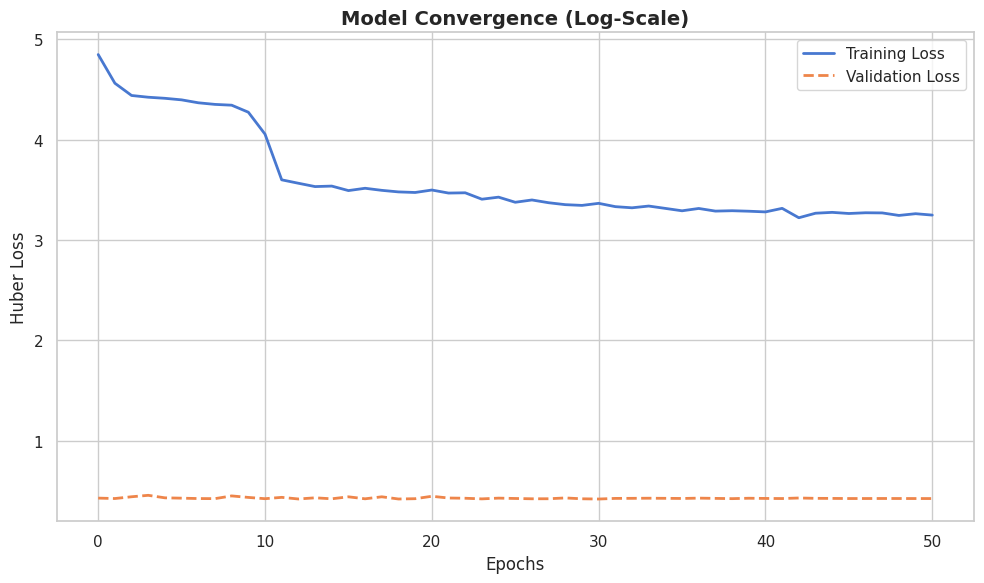

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss', linewidth=2)
plt.plot(val_loss_history, label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Model Convergence (Log-Scale)')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.tight_layout()
plt.savefig('report_plots/04_Training_Convergence.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

In [30]:
print("\n--- [5/6] Evaluating Models (Converting from Log back to Minutes) ---")
model.load_state_dict(torch.load('sota_urban_causal_weights.pth', map_location=device, weights_only=True))
model.eval()

y_true_all, y_pred_all = [], []
m_true_all, m_pred_all = [], []

with torch.no_grad():
    for batch_X, batch_Xt, batch_Yd, batch_Ym in test_loader:
        batch_X, batch_Xt = batch_X.to(device), batch_Xt.to(device)
        pred_factual, _, _, pred_m, A_causal_learned = model(batch_X, batch_Xt)

        # Convert log values BACK to real minutes for evaluation
        actual_mins = torch.expm1(batch_Yd).cpu().numpy()
        pred_mins = torch.expm1(pred_factual).cpu().numpy()

        y_true_all.extend(actual_mins)
        y_pred_all.extend(pred_mins)
        m_true_all.extend(batch_Ym.cpu().numpy())
        m_pred_all.extend(torch.argmax(pred_m, dim=1).cpu().numpy())

y_true_all, y_pred_all = np.array(y_true_all), np.array(y_pred_all)

mae = np.mean(np.abs(y_true_all - y_pred_all))
rmse = np.sqrt(np.mean(np.square(y_true_all - y_pred_all)))
r2 = r2_score(y_true_all, y_pred_all)
print(f"🏆 REAL-WORLD METRICS | MAE: {mae:.2f} mins | RMSE: {rmse:.2f} mins | R2 Score: {r2:.2f}")


--- [5/6] Evaluating Models (Converting from Log back to Minutes) ---
🏆 REAL-WORLD METRICS | MAE: 50.71 mins | RMSE: 122.61 mins | R2 Score: -0.05


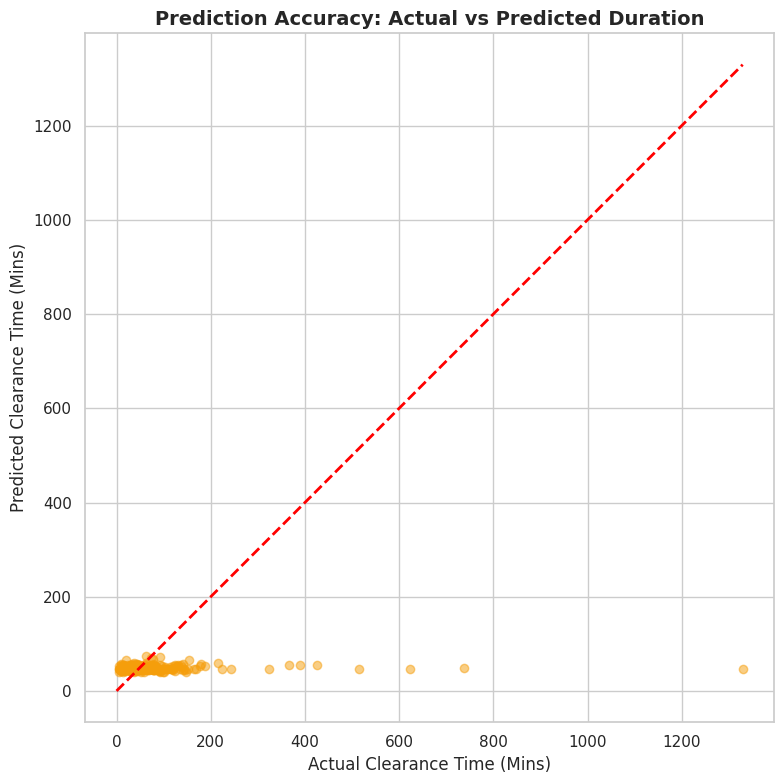

In [31]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true_all, y_pred_all, alpha=0.5, color='#F59E0B')
max_val = max(max(y_true_all), max(y_pred_all))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)
plt.title('Prediction Accuracy: Actual vs Predicted Duration')
plt.xlabel('Actual Clearance Time (Mins)')
plt.ylabel('Predicted Clearance Time (Mins)')
plt.tight_layout()
plt.savefig('report_plots/05_Scatter_Accuracy.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

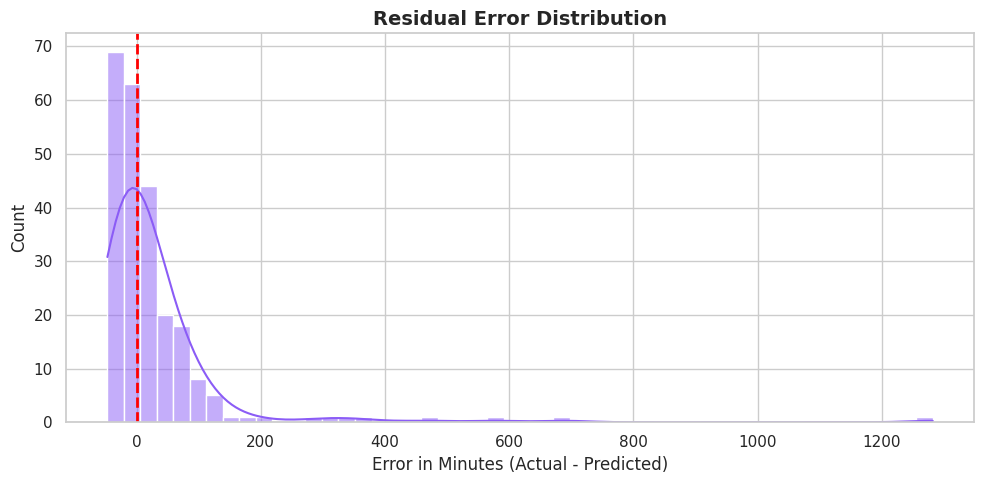

In [32]:
errors = y_true_all - y_pred_all
plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=50, kde=True, color='#8B5CF6')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Error Distribution')
plt.xlabel('Error in Minutes (Actual - Predicted)')
plt.tight_layout()
plt.savefig('report_plots/06_Error_Distribution.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

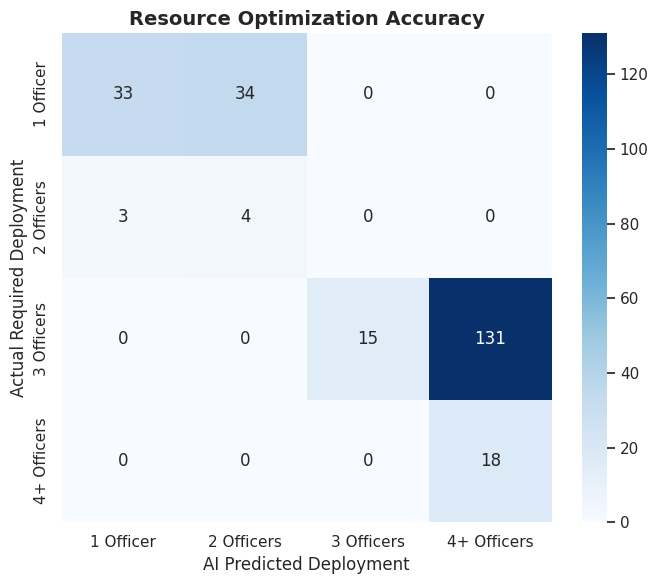

In [33]:
cm = confusion_matrix(m_true_all, m_pred_all)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1 Officer', '2 Officers', '3 Officers', '4+ Officers'],
            yticklabels=['1 Officer', '2 Officers', '3 Officers', '4+ Officers'])
plt.title('Resource Optimization Accuracy')
plt.xlabel('AI Predicted Deployment')
plt.ylabel('Actual Required Deployment')
plt.tight_layout()
plt.savefig('report_plots/07_Resource_Confusion_Matrix.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()

In [34]:
print("\n--- [6/6] Generating Causal Intervention Scenarios ---")
best_idx, max_saved, dur_no_best, dur_yes_best = 0, 0, 0, 0

with torch.no_grad():
    for i in range(len(test_dataset)):
        x, xt, _, _ = test_dataset[i]
        x = x.unsqueeze(0).to(device)
        xt = xt.unsqueeze(0).to(device)

        # Forward pass gives us BOTH scenarios instantly!
        _, pred_control, pred_treated, _, _ = model(x, xt)

        dur_no = torch.expm1(pred_control).item()
        dur_yes = torch.expm1(pred_treated).item()

        saved = dur_no - dur_yes
        if saved > max_saved:
            max_saved = saved
            best_idx = i
            dur_no_best = dur_no
            dur_yes_best = dur_yes


--- [6/6] Generating Causal Intervention Scenarios ---


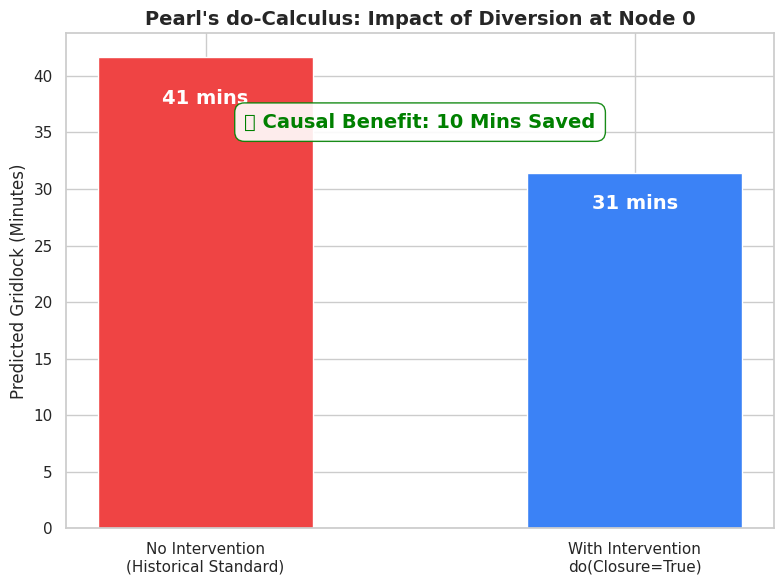

In [35]:
plt.figure(figsize=(8, 6))
bars = plt.bar(['No Intervention\n(Historical Standard)', 'With Intervention\ndo(Closure=True)'],
               [dur_no_best, dur_yes_best], color=['#EF4444', '#3B82F6'], width=0.5)
plt.title(f'Pearl\'s do-Calculus: Impact of Diversion at Node {int(test_dataset[best_idx][0][0,0].item())}')
plt.ylabel('Predicted Gridlock (Minutes)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - (yval * 0.1), f'{int(yval)} mins', ha='center', color='white', fontweight='bold', fontsize=14)
plt.text(0.5, max(dur_no_best, dur_yes_best) * 0.85, f"🔥 Causal Benefit: {int(max_saved)} Mins Saved",
         ha='center', fontsize=14, fontweight='bold', color='green', bbox=dict(facecolor='white', alpha=0.9, edgecolor='green', boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.savefig('report_plots/08_Causal_Intervention_Impact.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()


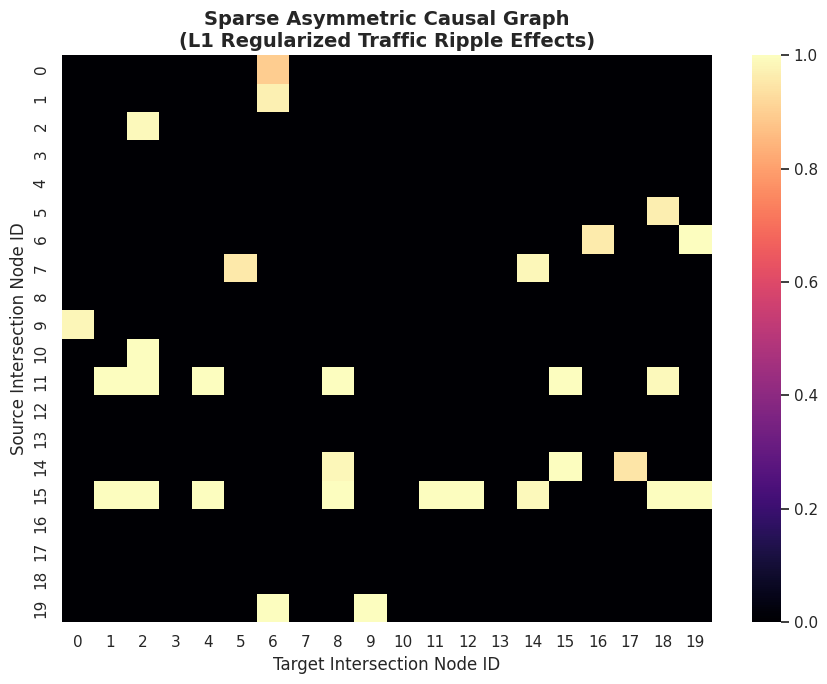

In [36]:
plt.figure(figsize=(9, 7))
subset_A = A_causal_learned.detach().cpu().numpy()[:20, :20]
sns.heatmap(subset_A, cmap='magma', annot=False)
plt.title('Sparse Asymmetric Causal Graph\n(L1 Regularized Traffic Ripple Effects)')
plt.xlabel('Target Intersection Node ID')
plt.ylabel('Source Intersection Node ID')
plt.tight_layout()
plt.savefig('report_plots/09_Learned_Causal_Graph.png', dpi=300)
plt.show() # PRINT TO SCREEN
plt.close()